In [1]:
# Incoding categorical variable 
# Data science tools work only with numberical data
# convert tect data into numerical form
# encoding is essential before training a model on a dataset
# categorical variables sucn as gender , city, country, payment type must be converted
# encoding imopact model accuracy & interpretability
# machine learning models operate onky on numerical data

In [2]:
# common method
# one-hot encoding -  unordered categories, we binary column
# ordinal encoing - order data, low mediam high

In [3]:
# key consideration before encoding
# combine rare categories into other
# be aware of the curse of dimensionality in high- cardinality feature
# always inspect the data after encoding using .head() & .info()

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# sample data
df = pd.DataFrame({
    "City":["Lahore","Karachi","Islamabad","Lahore","Karachi"],
    "Segment":["A","B","A","C","B"],
    "Sales":[200,240,180,300,220]
})
print(df)

        City Segment  Sales
0     Lahore       A    200
1    Karachi       B    240
2  Islamabad       A    180
3     Lahore       C    300
4    Karachi       B    220


In [6]:
# one-hot encode
encoded = pd.get_dummies(df,columns=["City","Segment"],drop_first=True)
print(encoded)

   Sales  City_Karachi  City_Lahore  Segment_B  Segment_C
0    200         False         True      False      False
1    240          True        False       True      False
2    180         False        False      False      False
3    300         False         True      False       True
4    220          True        False       True      False


In [7]:
from sklearn.preprocessing import OrdinalEncoder

In [8]:
df2 = pd.DataFrame({
    "Size":["Small","Mediam","Large","Mediam","Large"]
})

In [9]:
encoder = OrdinalEncoder(categories=[["Small","Mediam","Large"]])
df2["Size_encoded"] = encoder.fit_transform(df2[["Size"]])
print(df2)

     Size  Size_encoded
0   Small           0.0
1  Mediam           1.0
2   Large           2.0
3  Mediam           1.0
4   Large           2.0


In [10]:
# Feature Scaling & normalization 
# Scaling ensure features are on a similar range to improve distance-based model performance

In [11]:
# method of scaling
# z-score standardization
# min-max scaling (normalization)

In [12]:
# data leakage risk
# applyling scaling on both training * test data together leads to data leakage, as test data information is used during training

In [13]:
# when & why to scale
# scalefeature when using distance-based models (KNN,SVM,PCA,clustering)
# avoid or handle carefully for tree based models( decision trees, random forest), as they are insensitive to scale


In [17]:
df = pd.read_csv("./files/telecom_customer_churn_feature_engineering.csv")

In [18]:
# inspect raw data
df[["monthly_income","monthly_bill"]].head()

,monthly_income,monthly_bill
0,57643.0,10049.0
1,18207.0,2752.0
2,13075.0,3155.0
3,38890.0,5859.0
4,17475.0,5106.0


In [19]:
# why scaling is required
df[["monthly_income","monthly_bill"]].describe() # income dominates numerically - models will focus more on income


,monthly_income,monthly_bill
count,1200.000000,1200.000000
mean,31155.975833,5939.150833
std,19351.937726,4046.473963
min,4984.000000,710.000000
25%,17795.000000,3291.750000
50%,26628.000000,4871.000000
75%,39886.250000,7485.500000
max,209790.000000,36361.000000


In [20]:
# z-score scaling standardization (manual)
# 1- calculate mean & std
income_mean = df["monthly_income"].mean()
income_std = df["monthly_income"].std()

print("Mean: ",income_mean)
print("Std: ",income_std)

Mean:  31155.975833333334
Std:  19351.937725889493


In [21]:
# 2- apply z-score formula
df["income_zscore"]=(
    df["monthly_income"] - income_mean
)/income_std
df[["monthly_income","income_zscore"]].head()

,monthly_income,income_zscore
0,57643.0,1.368701
1,18207.0,-0.669131
2,13075.0,-0.934324
3,38890.0,0.399651
4,17475.0,-0.706956


In [24]:
#  verify z-score scaling
df["income_zscore"].mean(),df["income_zscore"].std()

(np.float64(-1.628327102783563e-17), 0.9999999999999997)

In [27]:
# min max scaling normalization (manual)
bill_min = df["monthly_bill"].min()
bill_max=df["monthly_bill"].max()
print("Min: ",bill_min)
print("Max: ",bill_max)

Min:  710.0
Max:  36361.0


In [28]:
# apply min max formula
df["bill_minmax"]=(
    df["monthly_bill"]-bill_min
)/(bill_max-bill_min)
df[["monthly_bill","bill_minmax"]].head()

,monthly_bill,bill_minmax
0,10049.0,0.261956
1,2752.0,0.057277
2,3155.0,0.068582
3,5859.0,0.144428
4,5106.0,0.123306


In [29]:
# verify min max scaling
df["bill_minmax"].min(),df["bill_minmax"].max()

(0.0, 1.0)

In [31]:
# show minimam, maximam, and a mid value together
df.loc[
    [df["monthly_bill"].idxmin(),
     df["monthly_bill"].idxmax(),
     df["monthly_bill"].sort_values().index[len(df)//2]],
    ["monthly_bill","bill_minmax"]
    ]
         

,monthly_bill,bill_minmax
893,710.0,0.000000
968,36361.0,1.000000
47,4873.0,0.116771


In [32]:
# side by side comparison
df[["monthly_income","income_zscore",
    "monthly_bill","bill_minmax"]].head()

,monthly_income,income_zscore,monthly_bill,bill_minmax
0,57643.0,1.368701,10049.0,0.261956
1,18207.0,-0.669131,2752.0,0.057277
2,13075.0,-0.934324,3155.0,0.068582
3,38890.0,0.399651,5859.0,0.144428
4,17475.0,-0.706956,5106.0,0.123306


In [34]:
# data leakage wrong (scaling before split)
df_scaled_wrong = (df["monthly_income"]-df["monthly_income"].mean())/df["monthly_income"].std()
df_scaled_wrong.head()

0    1.368701
1   -0.669131
2   -0.934324
3    0.399651
4   -0.706956
Name: monthly_income, dtype: float64

In [35]:
# Feature transformations
# purpose of transformation
# reduce skewness
# handle outlier

In [36]:
# common transformations
# log transform
# box-cox /yeo-johnson method

In [37]:
# outliers
# outliers are extreme values that lie far from the main data distribution & can negative affect machine learning model performance
# outlier handling methods
# clipping
# winsorization

In [38]:
# see the problem
df[["monthly_income","monthly_bill"]].describe()

,monthly_income,monthly_bill
count,1200.000000,1200.000000
mean,31155.975833,5939.150833
std,19351.937726,4046.473963
min,4984.000000,710.000000
25%,17795.000000,3291.750000
50%,26628.000000,4871.000000
75%,39886.250000,7485.500000
max,209790.000000,36361.000000


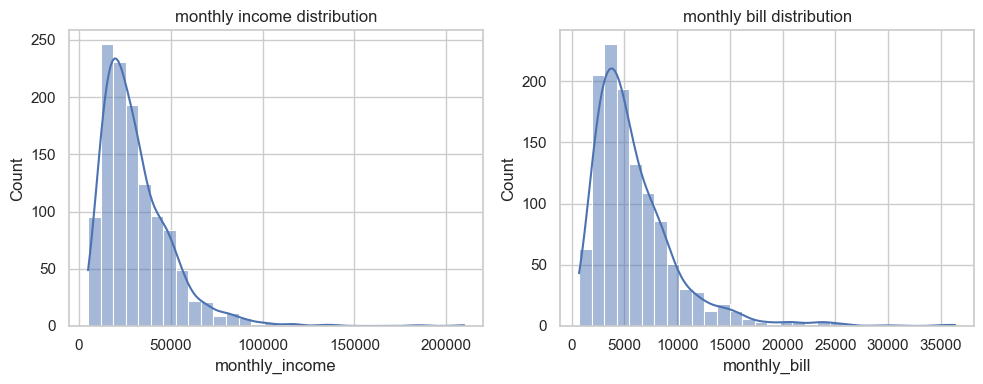

In [41]:
sns.set(style="whitegrid")
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df["monthly_income"],kde=True,bins=30)
plt.title("monthly income distribution")
plt.subplot(1,2,2)
sns.histplot(df["monthly_bill"],kde=True,bins=30)
plt.title("monthly bill distribution")
plt.tight_layout()
plt.show()

In [42]:
# max >> mean
# strong skew present
# ideal candidate for transformation

In [43]:
df["income_log"] = np.log1p(df["monthly_income"])
df[["monthly_income","income_log"]].head()

,monthly_income,income_log
0,57643.0,10.962041
1,18207.0,9.809616
2,13075.0,9.478534
3,38890.0,10.568518
4,17475.0,9.768584


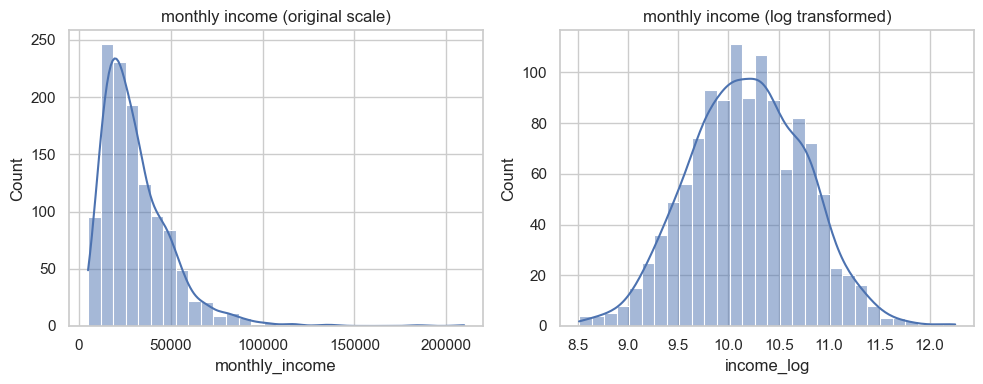

In [46]:
sns.set(style="whitegrid")
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df["monthly_income"],kde=True,bins=30)
plt.title("monthly income (original scale)")

plt.subplot(1,2,2)
sns.histplot(df["income_log"],kde=True,bins=30)
plt.title("monthly income (log transformed)")

plt.tight_layout()
plt.show()

In [47]:
# before vs after
df[["monthly_income","income_log"]].describe()

,monthly_income,income_log
count,1200.000000,1200.000000
mean,31155.975833,10.185955
std,19351.937726,0.566190
min,4984.000000,8.514189
25%,17795.000000,9.786729
50%,26628.000000,10.189755
75%,39886.250000,10.593811
max,209790.000000,12.253867


In [50]:
# clipping
upper_limit = df["monthly_bill"].quantile(0.99)
df["bill_clipped"]= df["monthly_bill"].clip(upper=upper_limit)
df.loc[
    [df["monthly_bill"].idxmax(),
        df["monthly_bill"].sort_values().index[len(df)//2]],
     ["monthly_bill","bill_clipped"]
    ]

,monthly_bill,bill_clipped
968,36361.0,21696.4
47,4873.0,4873.0


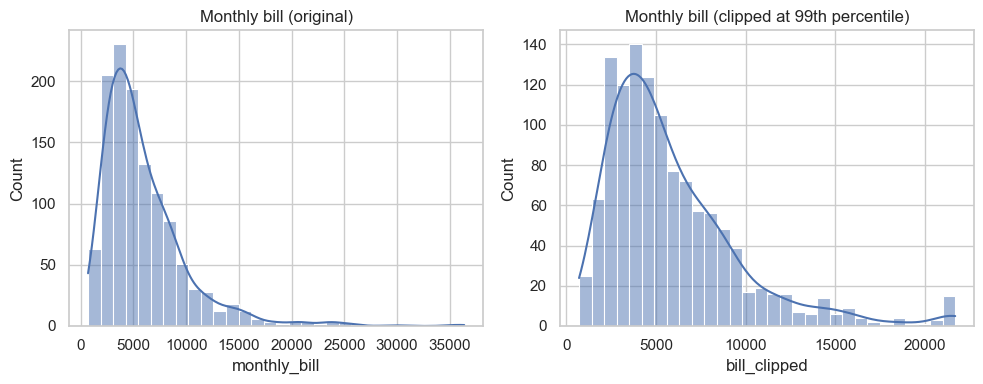

In [52]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df["monthly_bill"],kde=True,bins=30)
plt.title("Monthly bill (original)")

plt.subplot(1,2,2)
sns.histplot(df["bill_clipped"],kde=True,bins=30)
plt.title("Monthly bill (clipped at 99th percentile)")

plt.tight_layout()
plt.show()

In [54]:
from scipy.stats.mstats import winsorize

In [57]:
# winsorize: cap only the top 10%
df["bill_winsor"] =winsorize(
    df["monthly_bill"],
    limits=[0.01,0.01] # [lower_cap, upper_cap]
)

# check effect on extreme values
df.loc[
    [df["monthly_bill"].idxmin(),
        df["monthly_bill"].idxmax()],
    ["bill_winsor"]
    ]

,bill_winsor
893,1140.0
968,21682.0


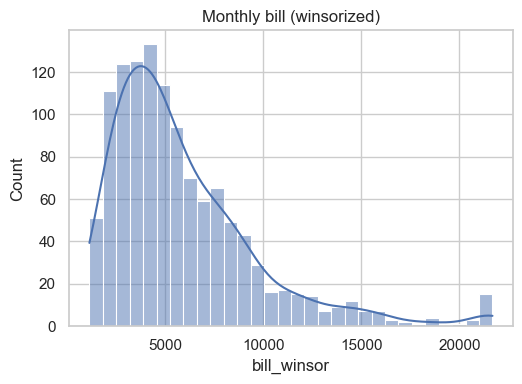

In [60]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,2)
sns.histplot(df["bill_winsor"],kde=True,bins=30)
plt.title("Monthly bill (winsorized)")

plt.tight_layout()
plt.show()